# <center>Case Study 8: Bases and Reconstruction Methods</center>

Compare RAVEN SparseSensing basis choices and the explicit `reconstructionMethod` options against pySensors on the same 2D parameter-time tensor family.

In [1]:

import os
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display
import numpy as np
import pandas as pd
import pysensors as ps


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "ravenframework").is_dir() and (path / "tests").is_dir():
            return path
    raise RuntimeError("Could not locate the repository root from the current working directory.")


repo_root = find_repo_root()
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.22})
seed = 42

import importlib.util
module_path = repo_root / "ravenframework" / "Models" / "PostProcessors" / "SparseSensingBases.py"
spec = importlib.util.spec_from_file_location("SparseSensingBases", module_path)
SparseSensingBases = importlib.util.module_from_spec(spec)
spec.loader.exec_module(SparseSensingBases)
HOSVDBasis = SparseSensingBases.HOSVDBasis

NX = 18
NY = 12
NT = 8
x_axis = np.linspace(0.0, 1.0, NX)
y_axis = np.linspace(0.0, 1.0, NY)
times = np.linspace(0.0, 1.0, NT)
XX, YY = np.meshgrid(x_axis, y_axis, indexing="xy")
X = XX.ravel()
Y = YY.ravel()
point_id = np.arange(X.size)
alphas = np.linspace(0.1, 1.0, 5)


def two_dimensional_field(alpha):
    left = np.exp(-(((X - (0.25 + 0.10 * alpha)) / 0.16) ** 2 + ((Y - 0.35) / 0.18) ** 2))
    right = np.exp(-(((X - 0.72) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha)) / 0.16) ** 2))
    wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
    return (
        np.exp(-0.85 * times[:, None]) * ((2.0 + 0.25 * alpha) * left[None, :] + (0.6 + 1.35 * alpha) * right[None, :])
        + 0.28 * np.cos(2.0 * np.pi * times[:, None]) * wave[None, :]
    )


def full_tensor():
    base = np.stack([two_dimensional_field(alpha) for alpha in alphas])
    extra_mode = (
        0.18
        * np.linspace(-1.0, 1.0, len(alphas))[:, None, None]
        * np.sin(np.pi * times)[None, :, None]
        * np.sin(3.0 * np.pi * X)[None, None, :]
    )
    return base + extra_mode


def field_image(values):
    return np.asarray(values, dtype=float).reshape(NY, NX)


def spatial_frame(ax, values, title, limits=None, cmap="coolwarm", sensors=None):
    if limits is None:
        limits = (float(np.nanmin(values)), float(np.nanmax(values)))
    image = ax.imshow(
        field_image(values),
        extent=[x_axis.min(), x_axis.max(), y_axis.min(), y_axis.max()],
        origin="lower",
        cmap=cmap,
        vmin=limits[0],
        vmax=limits[1],
        interpolation="bicubic",
        aspect="equal",
    )
    if sensors is not None:
        sensors = np.asarray(sensors, dtype=int)
        ax.scatter(X[sensors], Y[sensors], facecolors="none", edgecolors="black", s=82, linewidths=1.2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    return image


def nearest_point_indices(frame, x_col="x", y_col="y"):
    grid = np.column_stack([X, Y])
    indices = []
    distances = []
    for _, row in frame.iterrows():
        point = np.array([row[x_col], row[y_col]])
        distance = np.linalg.norm(grid - point, axis=1)
        index = int(np.argmin(distance))
        indices.append(index)
        distances.append(float(distance[index]))
    return np.asarray(indices, dtype=int), np.asarray(distances)


def style_sensor_comparison(table, caption, columns=None):
    if columns is None:
        columns = [
            "case", "match", "order_match", "sensor_id", "pySensors order", "RAVEN order",
            "pySensors value", "RAVEN value", "pySensors coefficient",
            "pySensors x", "RAVEN x", "pySensors y", "RAVEN y", "nearest_grid_distance",
        ]
    visible_columns = [column for column in columns if column in table.columns]

    def highlight(row):
        sensor_match = bool(row.get("match", False))
        order_match = bool(row.get("order_match", True))
        if sensor_match and order_match:
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        if sensor_match:
            return ["background-color: #fff2cc; color: #4a3600" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "order_match": lambda value: "yes" if bool(value) else "no",
        "pySensors order": "{:.0f}",
        "RAVEN order": "{:.0f}",
        "pySensors value": "{:.6f}",
        "RAVEN value": "{:.6f}",
        "pySensors coefficient": "{:.6f}",
        "pySensors x": "{:.6f}",
        "RAVEN x": "{:.6f}",
        "pySensors y": "{:.6f}",
        "RAVEN y": "{:.6f}",
        "nearest_grid_distance": "{:.2e}",
    }
    return (
        table[visible_columns]
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in visible_columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )


def style_match_table(table, caption):
    def highlight(row):
        if bool(row.get("match", False)):
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "pySensors rmse": "{:.6e}",
        "RAVEN rec_rmse": "{:.6e}",
        "relative_l2": "{:.6e}",
        "rmse": "{:.6e}",
    }
    return (
        table
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in table.columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )

def compare_sensor_tables(case_name, pysensors_indices, raven_frame):
    raven_indices, raven_distances = nearest_point_indices(raven_frame)
    pysensors_compare = pd.DataFrame({"case": case_name, "sensor_id": np.asarray(pysensors_indices, dtype=int), "pySensors order": np.arange(1, len(pysensors_indices) + 1), "pySensors x": X[pysensors_indices], "pySensors y": Y[pysensors_indices]})
    raven_compare = pd.DataFrame({"case": case_name, "sensor_id": raven_indices, "RAVEN order": raven_frame["sensor"].to_numpy(), "RAVEN x": raven_frame["x"].to_numpy(), "RAVEN y": raven_frame["y"].to_numpy(), "nearest_grid_distance": raven_distances})
    comparison = pysensors_compare.merge(raven_compare, on=["case", "sensor_id"], how="outer")
    comparison = comparison.sort_values(["case", "pySensors order", "RAVEN order"], na_position="last").reset_index(drop=True)
    comparison["same sensor"] = comparison["pySensors order"].notna() & comparison["RAVEN order"].notna()
    comparison["same location"] = np.isclose(comparison["pySensors x"], comparison["RAVEN x"]) & np.isclose(comparison["pySensors y"], comparison["RAVEN y"])
    comparison["match"] = comparison[["same sensor", "same location"]].all(axis=1)
    comparison["order_match"] = comparison["pySensors order"].eq(comparison["RAVEN order"])
    return comparison, raven_indices


def run_raven(raven_case_dir, raven_input):
    raven_case_dir.mkdir(parents=True, exist_ok=True)
    raven_output = raven_case_dir / "outPP.csv"
    if raven_output.exists():
        raven_output.unlink()

    import subprocess
    run_env = os.environ.copy()
    run_env["PATH"] = f"{repo_root}{os.pathsep}{run_env.get('PATH', '')}"
    run_env["INSTALLATION_MANAGER"] = "CONDA"
    run_env["RAVEN_LIBS_NAME"] = "raven_spsl_043"
    run_env["PYTHON_COMMAND"] = sys.executable
    run_env.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "mpl_raven"))

    print(f"$ raven_framework {raven_input.name}")
    run_result = subprocess.run(["raven_framework", raven_input.name], cwd=str(raven_case_dir), env=run_env, text=True, capture_output=True)
    print(run_result.stdout)
    if run_result.stderr:
        print(run_result.stderr)
    if run_result.returncode != 0:
        raise RuntimeError(f"RAVEN failed with exit code {run_result.returncode}")
    if not raven_output.exists():
        raise RuntimeError(f"RAVEN completed but did not write {raven_output}")
    print(f"Fresh RAVEN run completed: {raven_output}")
    return pd.read_csv(raven_output)


def write_transient_external_model(raven_case_dir):
    (raven_case_dir / "genSparseSensingTransient2D.py").write_text(
        textwrap.dedent(
            """\
            import numpy as np

            NX = 18
            NY = 12
            NT = 8
            X_AXIS = np.linspace(0.0, 1.0, NX)
            Y_AXIS = np.linspace(0.0, 1.0, NY)
            TIMES = np.linspace(0.0, 1.0, NT)
            XX, YY = np.meshgrid(X_AXIS, Y_AXIS, indexing='xy')
            X = XX.ravel()
            Y = YY.ravel()
            ALPHAS = np.linspace(0.1, 1.0, 5)

            def read_alpha(Input, default=0.5):
              if isinstance(Input, dict):
                raw = Input.get('alpha', default)
              else:
                raw = getattr(Input, 'alpha', default)
              return float(np.asarray(raw).reshape(-1)[0])

            def two_dimensional_field(alpha):
              left = np.exp(-(((X - (0.25 + 0.10 * alpha)) / 0.16) ** 2 + ((Y - 0.35) / 0.18) ** 2))
              right = np.exp(-(((X - 0.72) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha)) / 0.16) ** 2))
              wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
              return (
                  np.exp(-0.85 * TIMES[:, None]) * ((2.0 + 0.25 * alpha) * left[None, :] + (0.6 + 1.35 * alpha) * right[None, :])
                  + 0.28 * np.cos(2.0 * np.pi * TIMES[:, None]) * wave[None, :]
              )

            def full_tensor():
              base = np.stack([two_dimensional_field(alpha) for alpha in ALPHAS])
              extra_mode = (
                  0.18
                  * np.linspace(-1.0, 1.0, len(ALPHAS))[:, None, None]
                  * np.sin(np.pi * TIMES)[None, :, None]
                  * np.sin(3.0 * np.pi * X)[None, None, :]
              )
              return base + extra_mode

            def run(self, Input):
              alpha = read_alpha(Input)
              alpha_index = int(np.argmin(np.abs(ALPHAS - alpha)))
              self.time = TIMES
              self.pointID = np.arange(X.size)
              self.x = X.copy()
              self.y = Y.copy()
              self.T = full_tensor()[alpha_index]
              self._indexMap = {'x': ['pointID'], 'y': ['pointID'], 'T': ['time', 'pointID']}
            """
        )
    )


def write_transient_xml(raven_case_dir, case_name, basis, n_modes, n_sensors, reconstruction_method="auto", metric=True, regularized_noise=None):
    raven_alpha_values = " ".join(f"{value:.17g}" for value in alphas)
    metric_xml = "<reconstructionMetrics>rmse</reconstructionMetrics>" if metric else ""
    regularization_xml = ""
    if reconstruction_method == "regularized":
        regularization_xml = "<reconstructionPrior>decreasing</reconstructionPrior>"
        if regularized_noise is not None:
            regularization_xml += f"<reconstructionNoise>{regularized_noise}</reconstructionNoise>"
    raven_input = raven_case_dir / f"{case_name}.xml"
    raven_input.write_text(
        textwrap.dedent(
            f"""\
            <?xml version="1.0" ?>
            <Simulation verbosity="quiet">
              <RunInfo><WorkingDir>.</WorkingDir><Sequence>sample, pp, print</Sequence><batchSize>1</batchSize></RunInfo>
              <Models><ExternalModel name="genT" subType="" ModuleToLoad="genSparseSensingTransient2D"><inputs>alpha</inputs><outputs>time, pointID, x, y, T</outputs></ExternalModel><PostProcessor name="mySPSL" subType="SparseSensing"><Goal subType="reconstruction"><features>x, y, T</features><target>T</target><basis>{basis}</basis><nModes>{n_modes}</nModes><nSensors>{n_sensors}</nSensors><optimizer>QR</optimizer><pivotParameter>time</pivotParameter><reshape>snapshot</reshape><reconstructionMethod>{reconstruction_method}</reconstructionMethod>{regularization_xml}{metric_xml}<seed>{seed}</seed></Goal></PostProcessor></Models>
              <Distributions><Uniform name="uniAlpha"><lowerBound>0.0</lowerBound><upperBound>1.0</upperBound></Uniform></Distributions>
              <Samplers><Grid name="alphaGrid"><variable name="alpha"><distribution>uniAlpha</distribution><grid construction="custom" type="value">{raven_alpha_values}</grid></variable></Grid></Samplers>
              <Steps><MultiRun name="sample"><Input class="DataObjects" type="PointSet">placeholder</Input><Model class="Models" type="ExternalModel">genT</Model><Sampler class="Samplers" type="Grid">alphaGrid</Sampler><Output class="DataObjects" type="DataSet">dataDS</Output></MultiRun><PostProcess name="pp"><Input class="DataObjects" type="DataSet">dataDS</Input><Model class="Models" type="PostProcessor">mySPSL</Model><Output class="DataObjects" type="DataSet">outPP</Output></PostProcess><IOStep name="print"><Input class="DataObjects" type="DataSet">outPP</Input><Output class="OutStreams" type="Print">outPP</Output></IOStep></Steps>
              <DataObjects><PointSet name="placeholder"><Input>alpha</Input><Output>OutputPlaceHolder</Output></PointSet><DataSet name="dataDS"><Input>alpha</Input><Output>x, y, T</Output><Index var="time">T</Index><Index var="pointID">x, y, T</Index></DataSet><DataSet name="outPP"><Output>x, y, T, rec_rmse</Output><Index var="sensor">x, y, T</Index></DataSet></DataObjects>
              <OutStreams><Print name="outPP"><type>csv</type><source>outPP</source><what>output</what></Print></OutStreams>
            </Simulation>
            """
        ).lstrip()
    )
    return raven_input


tensor = full_tensor()
snapshot_matrix = tensor.reshape(len(alphas) * len(times), X.size)
print(f"tensor shape: {tensor.shape}")
print(f"snapshot matrix shape: {snapshot_matrix.shape}")


tensor shape: (5, 8, 216)
snapshot matrix shape: (40, 216)


## Tensor rank and visual check

numerical rank: 11
energy at 12 modes: 1.000000000000


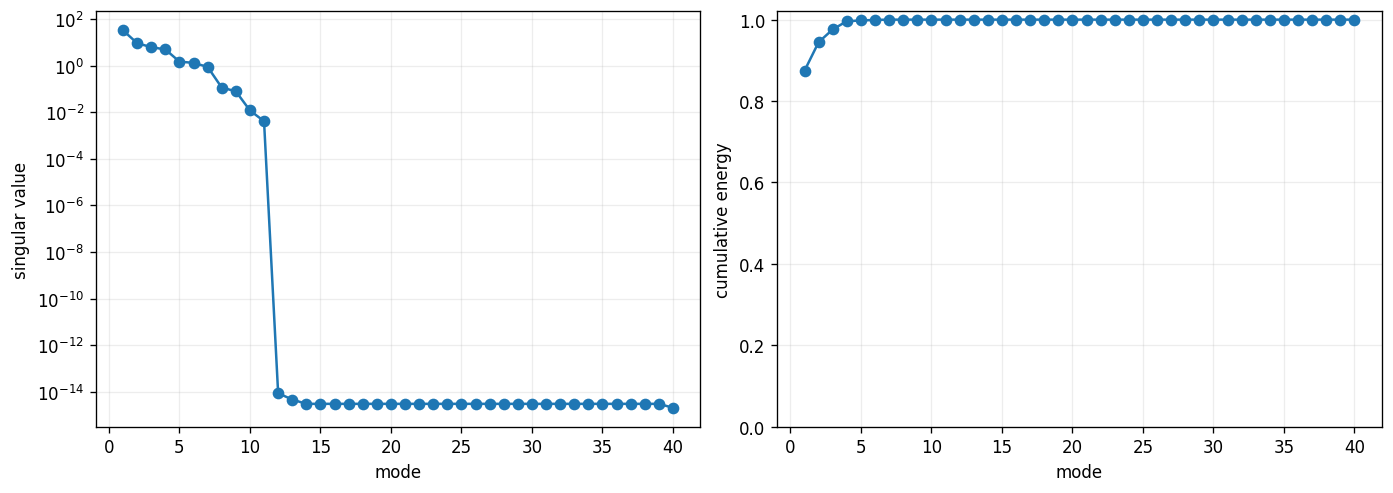

In [2]:

_, singular_values, _ = np.linalg.svd(snapshot_matrix, full_matrices=False)
energy = np.cumsum(singular_values ** 2) / np.sum(singular_values ** 2)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)
axes[0].semilogy(np.arange(1, len(singular_values) + 1), singular_values, marker="o")
axes[0].set_xlabel("mode")
axes[0].set_ylabel("singular value")
axes[1].plot(np.arange(1, len(energy) + 1), energy, marker="o")
axes[1].set_ylim(0.0, 1.02)
axes[1].set_xlabel("mode")
axes[1].set_ylabel("cumulative energy")
print(f"numerical rank: {np.linalg.matrix_rank(snapshot_matrix)}")
print(f"energy at 12 modes: {energy[11]:.12f}")


## pySensors / RAVEN PostProcessor mapping
<table style="width:100%; table-layout:fixed; border-collapse:collapse;">
<tr>
<th style="width:50%; text-align:left; padding:0.35rem; border-bottom:1px solid #bbb;">pySensors</th>
<th style="width:50%; text-align:left; padding:0.35rem; border-bottom:1px solid #bbb;">RAVEN PostProcessor XML</th>
</tr>
<tr>
<td style="vertical-align:top; padding:0.35rem;">

```python
basis = ps.basis.SVD(n_basis_modes=12, random_state=42)
model = ps.SSPOR(basis=basis, n_sensors=12, optimizer=ps.optimizers.QR())
model.fit(snapshot_matrix, seed=42)
y_hat = model.predict(snapshot_matrix[:, sensors], method="unregularized")
```

</td>
<td style="vertical-align:top; padding:0.35rem;">

```xml
<PostProcessor name="mySPSL" subType="SparseSensing">
  <Goal subType="reconstruction">
    <features>x, y, T</features>
    <target>T</target>
    <basis>SVD</basis>
    <nModes>12</nModes>
    <nSensors>12</nSensors>
    <optimizer>QR</optimizer>
    <pivotParameter>time</pivotParameter>
    <reshape>snapshot</reshape>
    <reconstructionMethod>auto</reconstructionMethod>
    <reconstructionMetrics>rmse</reconstructionMetrics>
    <seed>42</seed>
  </Goal>
</PostProcessor>
```

</td>
</tr>
</table>

## pySensors basis comparison

In [8]:

n_modes = 5 #12
n_sensors = 5 #12


def fit_pysensors_basis(basis_name):
    if basis_name == "Identity":
        basis = ps.basis.Identity(n_basis_modes=n_modes)
        model = ps.SSPOR(basis=basis, n_sensors=n_sensors, optimizer=ps.optimizers.QR())
        model.fit(snapshot_matrix, seed=seed)
    elif basis_name == "SVD":
        basis = ps.basis.SVD(n_basis_modes=n_modes, random_state=seed)
        model = ps.SSPOR(basis=basis, n_sensors=n_sensors, optimizer=ps.optimizers.QR())
        model.fit(snapshot_matrix, seed=seed)
    elif basis_name == "RandomProjection":
        basis = ps.basis.RandomProjection(n_basis_modes=n_modes, random_state=seed)
        model = ps.SSPOR(basis=basis, n_sensors=n_sensors, optimizer=ps.optimizers.QR())
        model.fit(snapshot_matrix, seed=seed)
    elif basis_name == "HOSVD":
        basis = HOSVDBasis(n_basis_modes=n_modes).fit(tensor)
        model = ps.SSPOR(basis=basis, n_sensors=n_sensors, optimizer=ps.optimizers.QR())
        model.fit(snapshot_matrix, prefit_basis=True, seed=seed)
    else:
        raise ValueError(basis_name)
    sensors = model.get_selected_sensors()
    pred = model.predict(snapshot_matrix[:, sensors], method="unregularized")
    rel_l2 = np.linalg.norm(snapshot_matrix - pred) / np.linalg.norm(snapshot_matrix)
    rmse = float(np.sqrt(np.mean((snapshot_matrix - pred) ** 2)))
    return model, sensors, rel_l2, rmse

basis_results = {}
for basis_name in ["Identity", "SVD", "RandomProjection", "HOSVD"]:
    model, sensors, rel_l2, rmse = fit_pysensors_basis(basis_name)
    basis_results[basis_name] = {"model": model, "sensors": sensors, "relative_l2": rel_l2, "rmse": rmse}

pd.DataFrame({"basis": name, "relative_l2": values["relative_l2"], "rmse": values["rmse"], "selected_sensors": list(values["sensors"])} for name, values in basis_results.items())


/Users/abdomg/miniconda3/envs/raven_spsl_043/lib/python3.11/site-packages/pysensors/basis/_identity.py:71: UserWarning: Only the first 5 examples were retained.
  warn(f"Only the first {self.n_basis_modes} examples were retained.")
/Users/abdomg/miniconda3/envs/raven_spsl_043/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:300: LinAlgWarning: Ill-conditioned matrix (rcond=1.88757e-17): result may not be accurate.
  self.basis_matrix_, solve(self.basis_matrix_[sensors, :], x, **solve_kws)


,basis,relative_l2,rmse,selected_sensors
0,Identity,0.537811,0.202376,"[77, 4, 14, 59, 58]"
1,SVD,0.051885,0.019524,"[76, 121, 79, 16, 111]"
2,RandomProjection,0.261810,0.098518,"[78, 121, 76, 111, 99]"
3,HOSVD,0.051885,0.019524,"[76, 121, 79, 16, 111]"


## Run fresh RAVEN basis cases

In [9]:

raven_base_dir = repo_root / "tutorials" / "SparseSensing" / "_raven_runs" / "08_bases_methods"
raven_base_dir.mkdir(parents=True, exist_ok=True)
write_transient_external_model(raven_base_dir)

all_comparisons = []
raven_basis_results = {}
for basis_name in ["Identity", "SVD", "RandomProjection", "HOSVD"]:
    raven_input = write_transient_xml(raven_base_dir, f"basis_{basis_name}", basis_name, n_modes, n_sensors, reconstruction_method="auto", metric=True)
    raven_frame = run_raven(raven_base_dir, raven_input)
    comparison, raven_indices = compare_sensor_tables(basis_name, basis_results[basis_name]["sensors"], raven_frame)
    all_comparisons.append(comparison)
    raven_basis_results[basis_name] = {"frame": raven_frame, "indices": raven_indices, "rec_rmse": float(raven_frame["rec_rmse"].iloc[0])}

comparison_table = pd.concat(all_comparisons, ignore_index=True)
summary = comparison_table.groupby("case").agg(match=("match", "all"), order_match=("order_match", "all"), rows=("sensor_id", "count"))
print(summary)
display(style_sensor_comparison(comparison_table, "RAVEN vs pySensors basis sensors"))


$ raven_framework basis_Identity.xml
CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #####     ###   ###  ########  ###    ###
     /     \  __  /    --###  ###    ###  ###   ###   ###  ###       #####  ###
    / /     \(  )/    --###  ###    ###   ##

case,match,order_match,sensor_id,pySensors order,RAVEN order,pySensors x,RAVEN x,pySensors y,RAVEN y,nearest_grid_distance
Identity,yes,yes,77,1,1,0.294118,0.294118,0.363636,0.363636,7.85e-17
Identity,yes,yes,4,2,2,0.235294,0.235294,0.000000,0.000000,2.78e-17
Identity,yes,yes,14,3,3,0.823529,0.823529,0.000000,0.000000,0.00e+00
Identity,yes,yes,59,4,4,0.294118,0.294118,0.272727,0.272727,5.55e-17
Identity,yes,yes,58,5,5,0.235294,0.235294,0.272727,0.272727,2.78e-17
SVD,yes,yes,76,1,1,0.235294,0.235294,0.363636,0.363636,6.21e-17
SVD,yes,yes,121,2,2,0.764706,0.764706,0.545455,0.545455,0.00e+00
SVD,yes,yes,79,3,3,0.411765,0.411765,0.363636,0.363636,5.55e-17
SVD,yes,yes,16,4,4,0.941176,0.941176,0.000000,0.000000,1.11e-16
SVD,yes,yes,111,5,5,0.176471,0.176471,0.545455,0.545455,0.00e+00


## Reconstruction method comparison

In [10]:

svd_model = basis_results["SVD"]["model"]
svd_sensors = basis_results["SVD"]["sensors"]
regularized_noise = 0.2
basis_matrix = svd_model.basis_matrix_
coeffs = np.linalg.lstsq(basis_matrix, snapshot_matrix.T, rcond=None)[0]
projection = (basis_matrix @ coeffs).T
basis_residual = np.linalg.norm(snapshot_matrix - projection) / np.linalg.norm(snapshot_matrix)
auto_method = "unregularized" if basis_residual <= 1e-10 and n_sensors >= n_modes else "regularized"
print(f"basis projection residual: {basis_residual:.3e}")
print(f"pySensors equivalent for RAVEN auto: {auto_method}")

method_rows = []
for method in ["auto", "unregularized", "regularized"]:
    if method == "regularized" or (method == "auto" and auto_method == "regularized"):
        pred = svd_model.predict(snapshot_matrix[:, svd_sensors], prior="decreasing", noise=regularized_noise)
        py_method = "regularized"
    else:
        pred = svd_model.predict(snapshot_matrix[:, svd_sensors], method="unregularized")
        py_method = "unregularized"
    py_rmse = float(np.sqrt(np.mean((snapshot_matrix - pred) ** 2)))
    raven_input = write_transient_xml(raven_base_dir, f"method_{method}", "SVD", n_modes, n_sensors, reconstruction_method=method, metric=True, regularized_noise=regularized_noise)
    raven_frame = run_raven(raven_base_dir, raven_input)
    method_rows.append({"reconstructionMethod": method, "pySensors path": py_method, "pySensors rmse": py_rmse, "RAVEN rec_rmse": float(raven_frame["rec_rmse"].iloc[0]), "match": np.isclose(py_rmse, float(raven_frame["rec_rmse"].iloc[0]), rtol=1e-10, atol=1e-10)})

method_table = pd.DataFrame(method_rows)
display(style_match_table(method_table, "RAVEN vs pySensors reconstruction method RMSE"))


basis projection residual: 4.539e-02
pySensors equivalent for RAVEN auto: regularized
$ raven_framework method_auto.xml
CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #####     ###   ###  ########  ###    ###
     /     \  __  /    --###  ###    ### 

reconstructionMethod,pySensors path,pySensors rmse,RAVEN rec_rmse,match
auto,regularized,6.080841e-02,2.211112e-01,no
unregularized,unregularized,1.952398e-02,1.952398e-02,yes
regularized,regularized,6.080841e-02,6.080841e-02,yes


basis,pySensors rmse,RAVEN rec_rmse,match
Identity,2.023764e-01,1.798290e-01,no
SVD,1.952398e-02,2.211112e-01,no
RandomProjection,9.851814e-02,1.260606e-01,no
HOSVD,1.952398e-02,2.211112e-01,no


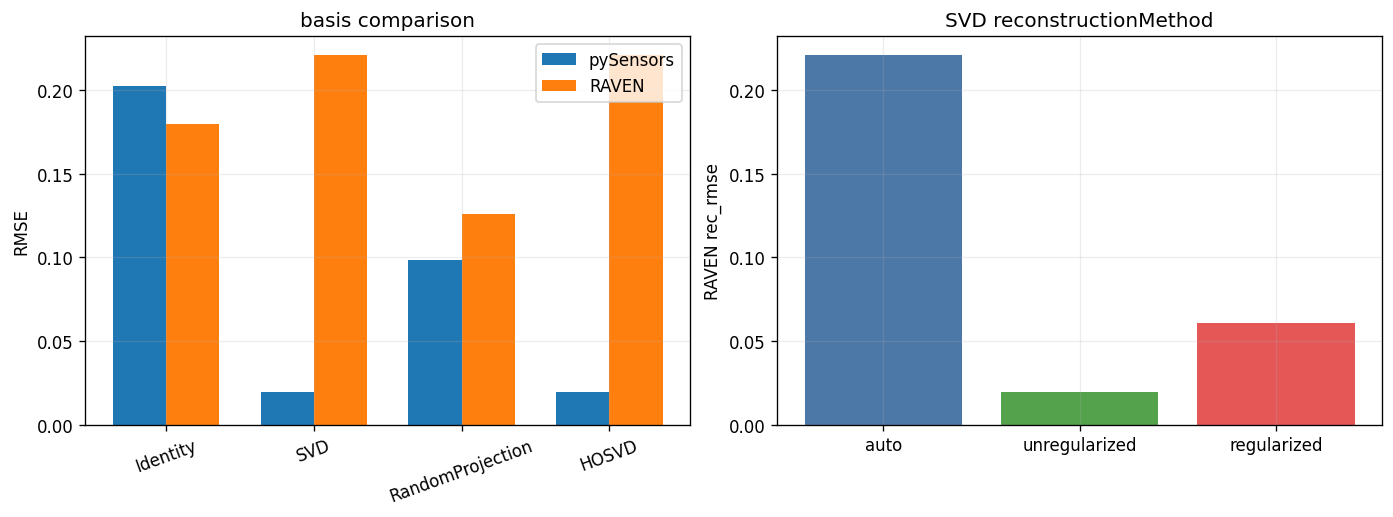

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
basis_table = pd.DataFrame({"basis": name, "pySensors rmse": values["rmse"], "RAVEN rec_rmse": raven_basis_results[name]["rec_rmse"]} for name, values in basis_results.items())
basis_table["match"] = np.isclose(basis_table["pySensors rmse"], basis_table["RAVEN rec_rmse"], rtol=1e-10, atol=1e-10)
axes[0].bar(np.arange(len(basis_table)) - 0.18, basis_table["pySensors rmse"], width=0.36, label="pySensors")
axes[0].bar(np.arange(len(basis_table)) + 0.18, basis_table["RAVEN rec_rmse"], width=0.36, label="RAVEN")
axes[0].set_xticks(np.arange(len(basis_table)), basis_table["basis"], rotation=20)
axes[0].set_ylabel("RMSE")
axes[0].set_title("basis comparison")
axes[0].legend()
axes[1].bar(method_table["reconstructionMethod"], method_table["RAVEN rec_rmse"], color=["#4c78a8", "#54a24b", "#e45756"])
axes[1].set_ylabel("RAVEN rec_rmse")
axes[1].set_title("SVD reconstructionMethod")
display(style_match_table(basis_table, "RAVEN vs pySensors basis RMSE"))


## Field Reconstruction Diagnostics
The HOSVD case is shown as a true field, reconstructed field, and relative-error field. The animation advances in time for one alpha value, with color representing temperature.


basis,relative_l2_error,rmse
HOSVD,5.188458e-02,1.952398e-02


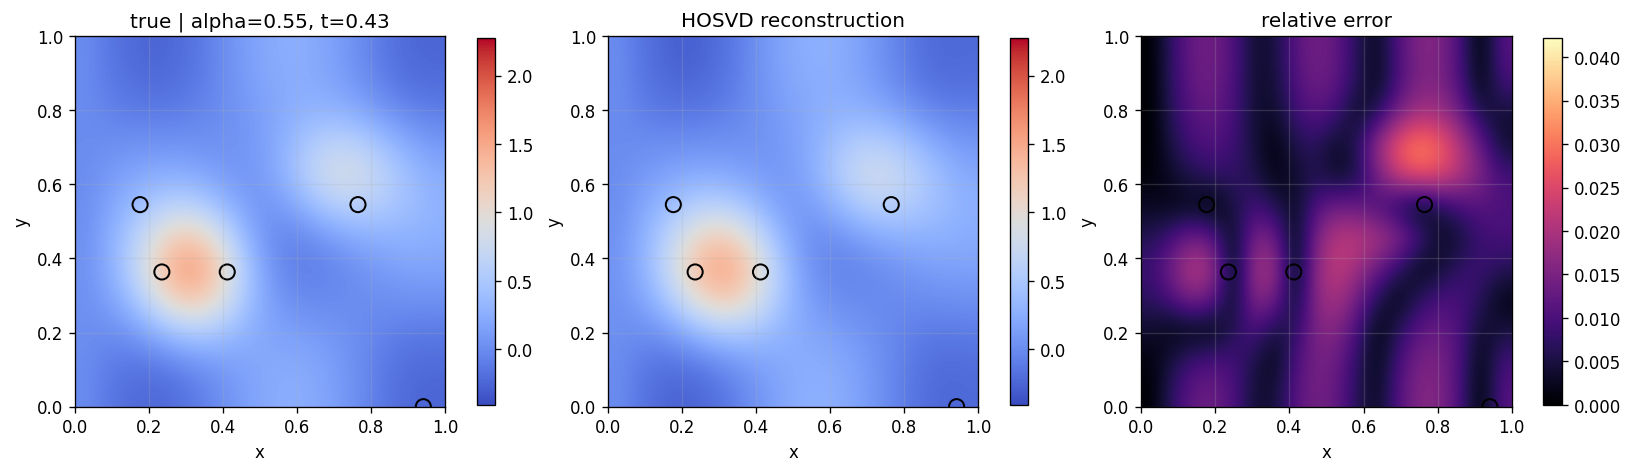

In [12]:

from matplotlib import animation

diagnostic_basis = "HOSVD"
diagnostic_model = basis_results[diagnostic_basis]["model"]
diagnostic_sensors = np.asarray(basis_results[diagnostic_basis]["sensors"], dtype=int)
diagnostic_reconstruction = diagnostic_model.predict(snapshot_matrix[:, diagnostic_sensors], method="unregularized")
truth_tensor = tensor
diagnostic_tensor = diagnostic_reconstruction.reshape(len(alphas), len(times), X.size)
diagnostic_relative_error = np.abs(diagnostic_tensor - truth_tensor) / max(float(np.max(np.abs(truth_tensor))), 1e-12)

diagnostic_summary = pd.DataFrame([{
    "basis": diagnostic_basis,
    "relative_l2_error": np.linalg.norm(diagnostic_reconstruction - snapshot_matrix) / max(np.linalg.norm(snapshot_matrix), 1e-12),
    "rmse": float(np.sqrt(np.mean((diagnostic_reconstruction - snapshot_matrix) ** 2))),
}])
display(diagnostic_summary.style.format({"relative_l2_error": "{:.6e}", "rmse": "{:.6e}"}).hide(axis="index"))

alpha_index = min(2, len(alphas) - 1)
time_index = min(3, len(times) - 1)
field_limits = (float(np.min(truth_tensor)), float(np.max(truth_tensor)))
error_limits = (0.0, max(float(np.max(diagnostic_relative_error)), 1e-12))
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), constrained_layout=True)
panels = [
    (truth_tensor[alpha_index, time_index], f"true | alpha={alphas[alpha_index]:.2f}, t={times[time_index]:.2f}", "coolwarm", field_limits),
    (diagnostic_tensor[alpha_index, time_index], f"{diagnostic_basis} reconstruction", "coolwarm", field_limits),
    (diagnostic_relative_error[alpha_index, time_index], "relative error", "magma", error_limits),
]
for ax, (values, title, cmap, limits) in zip(axes, panels):
    im = spatial_frame(ax, values, title, limits=limits, cmap=cmap, sensors=diagnostic_sensors)
    fig.colorbar(im, ax=ax, shrink=0.82)

fig_anim, anim_axes = plt.subplots(1, 3, figsize=(13.5, 4.0), constrained_layout=True)
truth_im = spatial_frame(anim_axes[0], truth_tensor[alpha_index, 0], "true", limits=field_limits, cmap="coolwarm", sensors=diagnostic_sensors)
recon_im = spatial_frame(anim_axes[1], diagnostic_tensor[alpha_index, 0], f"{diagnostic_basis} reconstruction", limits=field_limits, cmap="coolwarm", sensors=diagnostic_sensors)
error_im = spatial_frame(anim_axes[2], diagnostic_relative_error[alpha_index, 0], "relative error", limits=error_limits, cmap="magma", sensors=diagnostic_sensors)
fig_anim.colorbar(truth_im, ax=anim_axes[0], shrink=0.82)
fig_anim.colorbar(recon_im, ax=anim_axes[1], shrink=0.82)
fig_anim.colorbar(error_im, ax=anim_axes[2], shrink=0.82)

def update_time_frame(frame_index):
    truth_im.set_data(field_image(truth_tensor[alpha_index, frame_index]))
    recon_im.set_data(field_image(diagnostic_tensor[alpha_index, frame_index]))
    error_im.set_data(field_image(diagnostic_relative_error[alpha_index, frame_index]))
    anim_axes[0].set_title(f"true | t={times[frame_index]:.2f}")
    anim_axes[1].set_title(f"{diagnostic_basis} reconstruction | t={times[frame_index]:.2f}")
    anim_axes[2].set_title(f"relative error | t={times[frame_index]:.2f}")
    return truth_im, recon_im, error_im

field_animation = animation.FuncAnimation(fig_anim, update_time_frame, frames=len(times), interval=700, blit=False)
display(HTML(field_animation.to_jshtml()))
plt.close(fig_anim)
